# Analyze DPL Results

In [49]:
from pathlib import Path
import json
import pickle

import pandas as pd
import numpy as np

In [50]:
from temp import (
    mis_metrics,
    plot_mis_predictions
)

In [51]:
# Dataset configuration
dataset = "darpa2000"
scenario = "s1_inside"

logic_file = "darpa_neg"

## Load Original Flows

In [52]:
df = pd.read_csv(
    f"../data/interim/{dataset}/{scenario}/flows_labeled/all_flows_labeled.csv"
)

df = df.sort_values("start_time").reset_index(drop=True)
df['t_rel'] = df['start_time'] - df['start_time'].min()

In [53]:
phase_bounds = (
    df[df['phase'] > 0]
    .groupby('phase')['t_rel']
    .agg(['min', 'max'])
)

phase_start = phase_bounds['min'].to_dict()
phase_end   = phase_bounds['max'].to_dict()

In [54]:
phase_bounds

,min,max
phase,,
1,1799.665435,1824.341042
2,2790.877254,3333.974143
3,4294.134775,4402.837414
4,5305.272464,5357.444592
5,7478.960660,8383.254878


## Load DPL Dataset

In [55]:
def load_dpl_dataset(logic_file, cache_file_name):
    dpl_dataset_dir = Path(f"../experiments/{dataset}/{scenario}/deepproblog/{logic_file}/cache/")
    cache_file_test = dpl_dataset_dir / cache_file_name

    cache = pickle.load(open(cache_file_test, "rb"))
    cache_df = pd.DataFrame(cache)
    cache_df.head()

    return cache_df

## Load DPL Metrics

In [56]:
# --- Load metrics ---
metrics_dir = Path(f"../experiments/{dataset}/{scenario}/deepproblog/{logic_file}/metrics")
file_paths = list(metrics_dir.iterdir())

experiments = {}

for file_path in file_paths:
    experiment_name = file_path.stem[:-16]  # Remove "run_id"
    print(f"Processing {experiment_name}...")
    data = np.load(file_path, allow_pickle=True)
    experiments[experiment_name] = {
        "confusion_matrix": data["confusion_matrix"],
        "classes": data["classes"].tolist(),
        "metrics": data["metrics"].item(),
    }

Processing darpa_neg_pretrained_original_w10...
Processing darpa_neg_scratch_down_w10...
Processing darpa_neg_scratch_original_w10...
Processing darpa_neg_pretrained_down_w10...
Processing darpa_neg_pretrained_up_w10...
Processing darpa_neg_scratch_up_w10...


## Analyze Results

In [57]:
phase_map = {
    "benign": 0,
    "phase1": 1,
    "phase2": 2,
    "phase3": 3,
    "phase4": 4,
    "phase5": 5,
}

In [58]:
err_folder = Path(f"../experiments/{dataset}/{scenario}/deepproblog/{logic_file}/errors/")
file_paths = list(err_folder.iterdir())

Experiment: darpa_neg_pretrained_down_w10
{'accuracy': np.float64(0.9990859777058041), 'macro_precision': 1.0, 'macro_recall': 0.9346348136950062, 'macro_f1': 0.9640922813145961, 'false_alarms': 0, 'false_alarm_rate': np.float64(0.0), 'missed_attacks': 46, 'detection_rate': np.float64(0.9984368097325586), 'classes': ['benign', 'phase1', 'phase2', 'phase3', 'phase4', 'phase5'], 'per_class': {'benign': {'TP': 20900, 'FP': 46, 'FN': 0, 'precision': np.float64(0.997803876635157), 'recall': np.float64(1.0), 'f1': np.float64(0.9989007312526883), 'support': 20900}, 'phase1': {'TP': 8, 'FP': 0, 'FN': 0, 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'support': 8}, 'phase2': {'TP': 8, 'FP': 0, 'FN': 1, 'precision': np.float64(1.0), 'recall': np.float64(0.8888888888888888), 'f1': np.float64(0.9411764705882353), 'support': 9}, 'phase3': {'TP': 11, 'FP': 0, 'FN': 3, 'precision': np.float64(1.0), 'recall': np.float64(0.7857142857142857), 'f1': np.float64(0.88), 'sup

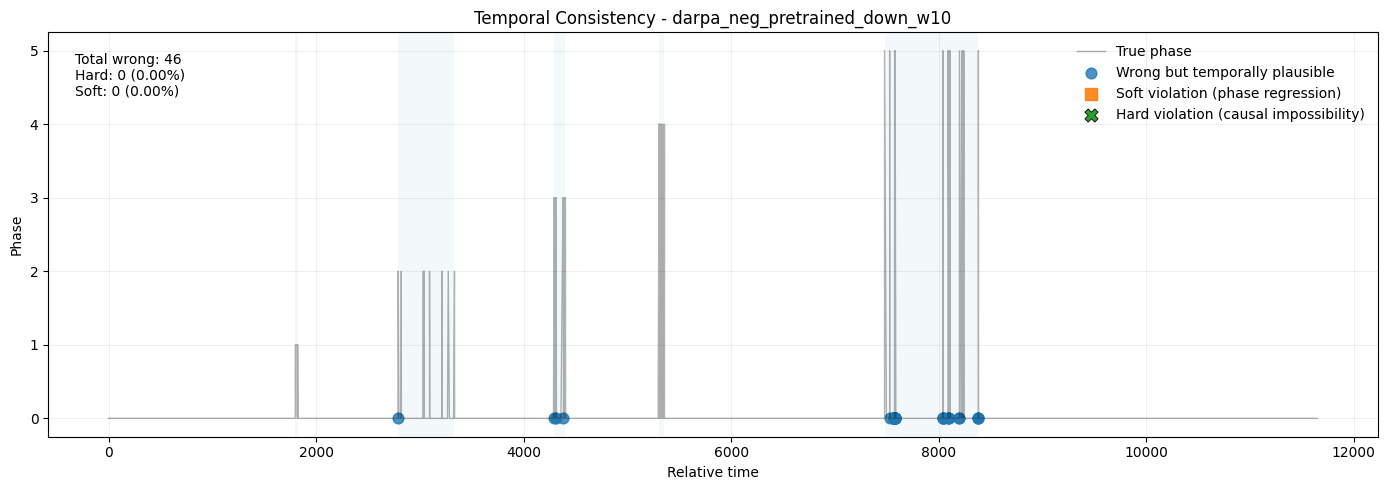

Experiment: darpa_neg_scratch_down_w10
{'accuracy': np.float64(0.9984898762095893), 'macro_precision': 0.9747957585866495, 'macro_recall': 0.9409840200442126, 'macro_f1': 0.9540142196104828, 'false_alarms': 31, 'false_alarm_rate': np.float64(0.0014832535885167463), 'missed_attacks': 45, 'detection_rate': np.float64(0.9984707921296768), 'classes': ['benign', 'phase1', 'phase2', 'phase3', 'phase4', 'phase5'], 'per_class': {'benign': {'TP': 20869, 'FP': 45, 'FN': 31, 'precision': np.float64(0.9978483312613561), 'recall': np.float64(0.9985167464114832), 'f1': np.float64(0.998182426938346), 'support': 20900}, 'phase1': {'TP': 8, 'FP': 0, 'FN': 0, 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'support': 8}, 'phase2': {'TP': 7, 'FP': 0, 'FN': 2, 'precision': np.float64(1.0), 'recall': np.float64(0.7777777777777778), 'f1': np.float64(0.8750000000000001), 'support': 9}, 'phase3': {'TP': 13, 'FP': 0, 'FN': 1, 'precision': np.float64(1.0), 'recall': np.float64(0.

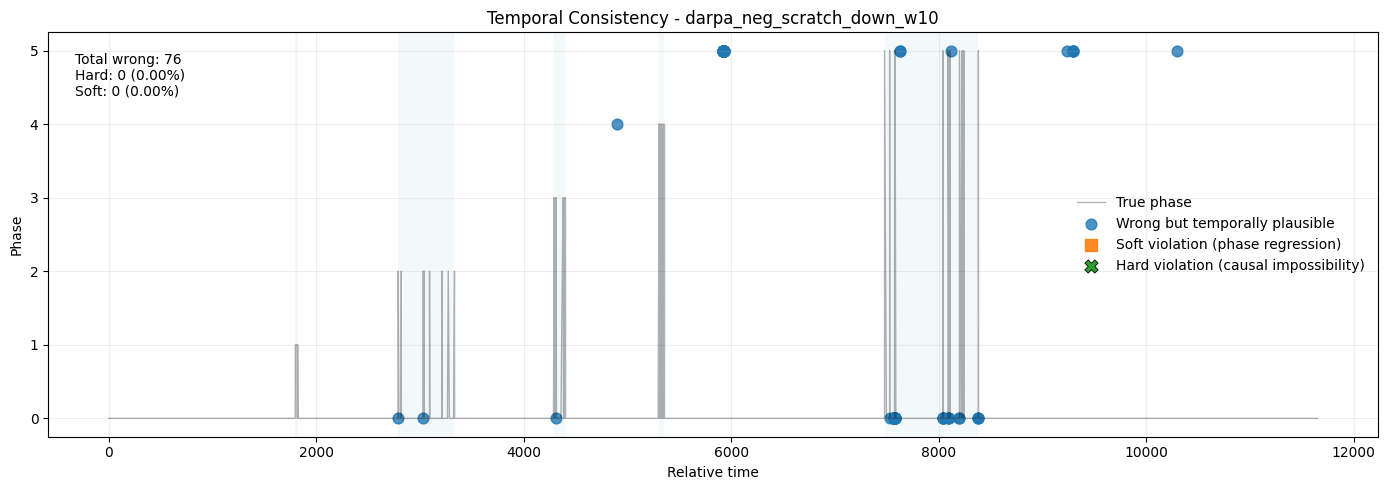

Experiment: darpa_neg_scratch_up_w10
{'accuracy': np.float64(0.9991257178055517), 'macro_precision': 0.975, 'macro_recall': 0.9854284644886571, 'macro_f1': 0.9791162464562083, 'false_alarms': 1, 'false_alarm_rate': np.float64(4.784688995215311e-05), 'missed_attacks': 43, 'detection_rate': np.float64(0.9985387569239134), 'classes': ['benign', 'phase1', 'phase2', 'phase3', 'phase4', 'phase5'], 'per_class': {'benign': {'TP': 20899, 'FP': 43, 'FN': 1, 'precision': np.float64(0.9979467099608442), 'recall': np.float64(0.9999521531100478), 'f1': np.float64(0.9989484250274843), 'support': 20900}, 'phase1': {'TP': 8, 'FP': 0, 'FN': 0, 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'support': 8}, 'phase2': {'TP': 9, 'FP': 0, 'FN': 0, 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'support': 9}, 'phase3': {'TP': 13, 'FP': 0, 'FN': 1, 'precision': np.float64(1.0), 'recall': np.float64(0.9285714285714286), 'f1': np.float64(0.96296296

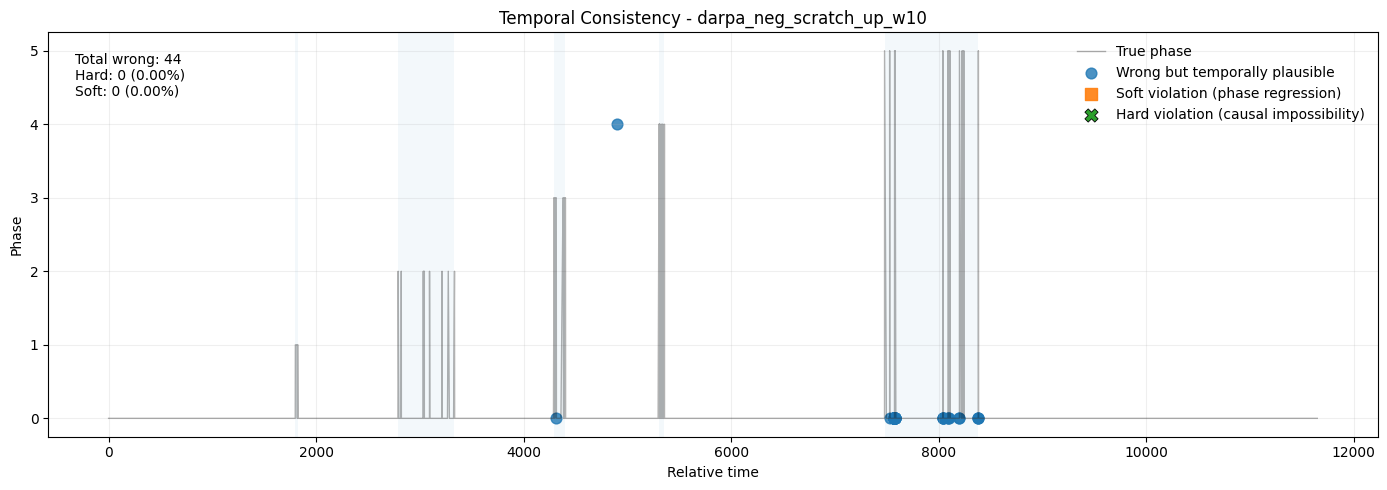

Experiment: darpa_neg_pretrained_up_w10
{'accuracy': np.float64(0.9990859777058041), 'macro_precision': 1.0, 'macro_recall': 0.9282856073457999, 'macro_f1': 0.9604723718123337, 'false_alarms': 0, 'false_alarm_rate': np.float64(0.0), 'missed_attacks': 46, 'detection_rate': np.float64(0.9984368097325586), 'classes': ['benign', 'phase1', 'phase2', 'phase3', 'phase4', 'phase5'], 'per_class': {'benign': {'TP': 20900, 'FP': 46, 'FN': 0, 'precision': np.float64(0.997803876635157), 'recall': np.float64(1.0), 'f1': np.float64(0.9989007312526883), 'support': 20900}, 'phase1': {'TP': 8, 'FP': 0, 'FN': 0, 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'support': 8}, 'phase2': {'TP': 9, 'FP': 0, 'FN': 0, 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'support': 9}, 'phase3': {'TP': 11, 'FP': 0, 'FN': 3, 'precision': np.float64(1.0), 'recall': np.float64(0.7857142857142857), 'f1': np.float64(0.88), 'support': 14}, 'phase4': {'TP': 6, 

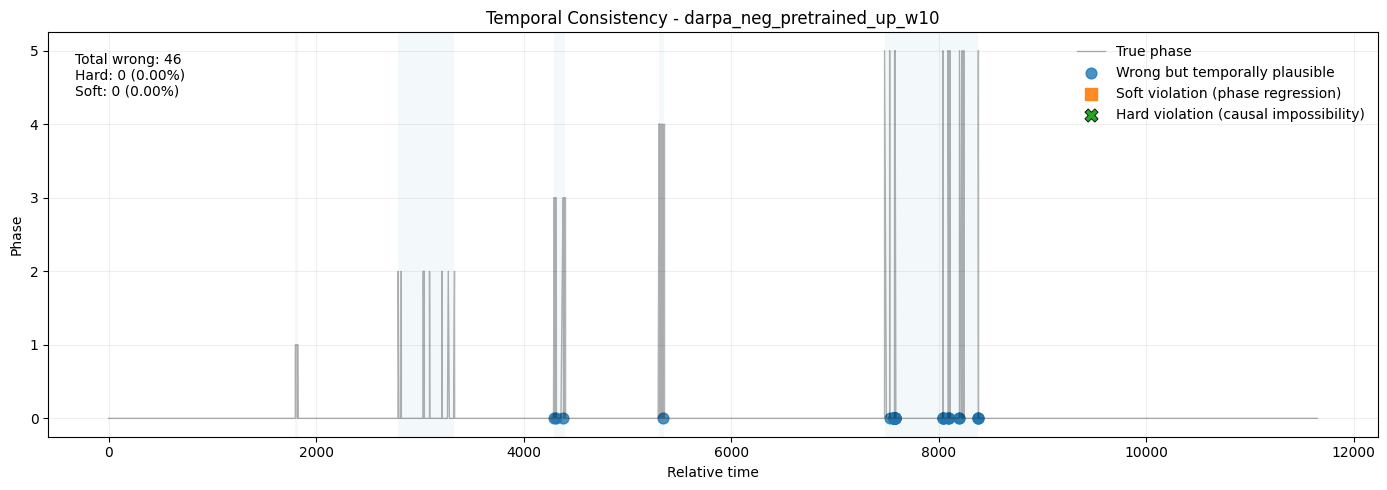

Experiment: darpa_neg_scratch_original_w10
{'accuracy': np.float64(0.9991058477556779), 'macro_precision': 0.975, 'macro_recall': 0.9632062422664347, 'macro_f1': 0.9673515405738554, 'false_alarms': 1, 'false_alarm_rate': np.float64(4.784688995215311e-05), 'missed_attacks': 44, 'detection_rate': np.float64(0.9985047745267951), 'classes': ['benign', 'phase1', 'phase2', 'phase3', 'phase4', 'phase5'], 'per_class': {'benign': {'TP': 20899, 'FP': 44, 'FN': 1, 'precision': np.float64(0.9978990593515733), 'recall': np.float64(0.9999521531100478), 'f1': np.float64(0.998924551298903), 'support': 20900}, 'phase1': {'TP': 8, 'FP': 0, 'FN': 0, 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'support': 8}, 'phase2': {'TP': 8, 'FP': 0, 'FN': 1, 'precision': np.float64(1.0), 'recall': np.float64(0.8888888888888888), 'f1': np.float64(0.9411764705882353), 'support': 9}, 'phase3': {'TP': 13, 'FP': 0, 'FN': 1, 'precision': np.float64(1.0), 'recall': np.float64(0.92857142857

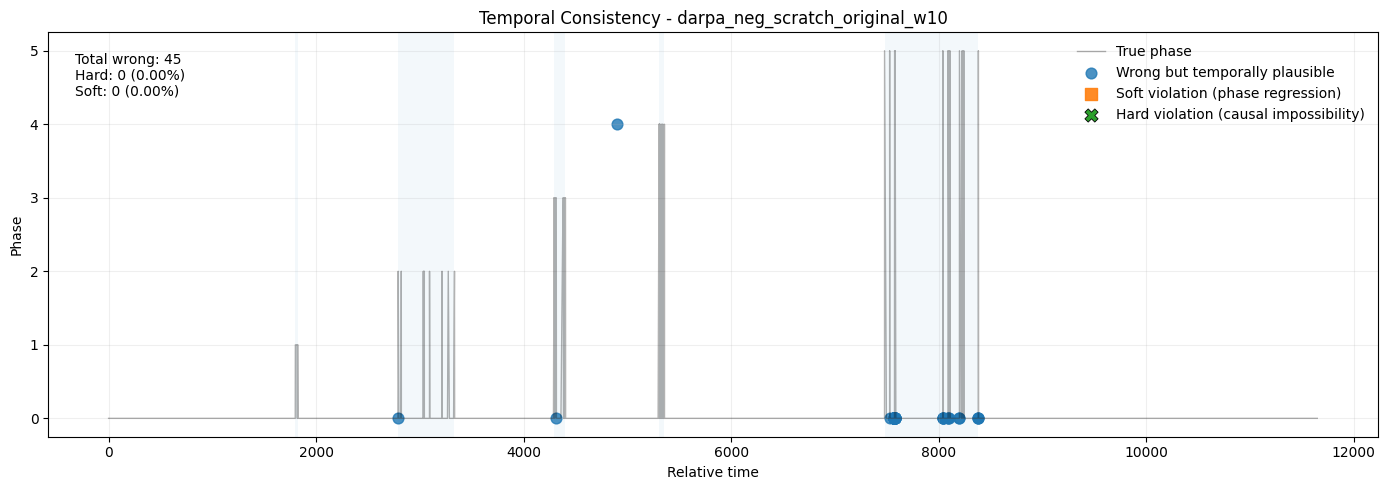

Experiment: darpa_neg_pretrained_original_w10
{'accuracy': np.float64(0.9990859777058041), 'macro_precision': 1.0, 'macro_recall': 0.9346348136950062, 'macro_f1': 0.9640922813145961, 'false_alarms': 0, 'false_alarm_rate': np.float64(0.0), 'missed_attacks': 46, 'detection_rate': np.float64(0.9984368097325586), 'classes': ['benign', 'phase1', 'phase2', 'phase3', 'phase4', 'phase5'], 'per_class': {'benign': {'TP': 20900, 'FP': 46, 'FN': 0, 'precision': np.float64(0.997803876635157), 'recall': np.float64(1.0), 'f1': np.float64(0.9989007312526883), 'support': 20900}, 'phase1': {'TP': 8, 'FP': 0, 'FN': 0, 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'support': 8}, 'phase2': {'TP': 8, 'FP': 0, 'FN': 1, 'precision': np.float64(1.0), 'recall': np.float64(0.8888888888888888), 'f1': np.float64(0.9411764705882353), 'support': 9}, 'phase3': {'TP': 11, 'FP': 0, 'FN': 3, 'precision': np.float64(1.0), 'recall': np.float64(0.7857142857142857), 'f1': np.float64(0.88), 

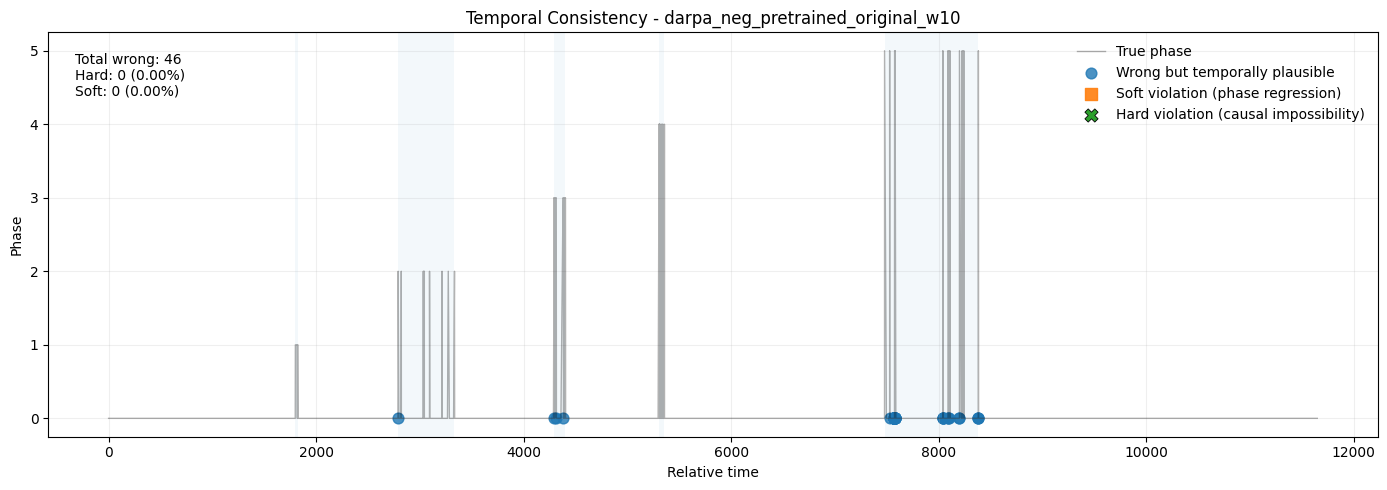

In [59]:
results = []

for file_path in file_paths:

    experiment_name = file_path.stem[:-16]

    # --- Compute mispredictions ---
    parts = experiment_name.split("_")
    cache_file_name = f"{parts[0]}_{parts[1]}_{parts[3]}_{parts[4]}_test.pkl"
    cache_df = load_dpl_dataset(logic_file, cache_file_name)

    with open(file_path, "r") as f:
        errors = json.load(f)
    
    dpl_to_orig = dict(zip(cache_df['dpl_index'], cache_df['orig_index']))

    original_indices = []
    mis_y_preds = []
    mis_y_trues = []

    for error in errors:
        dpl_index = error['index']

        original_indices.append(dpl_to_orig[dpl_index])
        y_pred = error['predicted']
        y_true = error['actual']
        mis_y_preds.append(phase_map[y_pred])
        mis_y_trues.append(phase_map[y_true])

    mis_df = df.loc[original_indices].copy()
    mis_df['y_pred'] = mis_y_preds
    mis_df['y_true'] = mis_y_trues

    # --- Compute violation categories ---
    wrong, hard, soft, plausible = mis_metrics(mis_df, phase_start)

    total_wrong = len(wrong)
    hard_rate = len(hard) / total_wrong if total_wrong > 0 else 0
    soft_rate = len(soft) / total_wrong if total_wrong > 0 else 0

    # --- Collect everything ---
    metrics = experiments[experiment_name]['metrics']
    print(f"Experiment: {experiment_name}")
    print(metrics)

    results.append({
        "model": f"{experiment_name}",
        "accuracy": metrics["accuracy"],
        "precision" : metrics["macro_precision"],
        "recall" : metrics["macro_recall"], 
        "f1": metrics["macro_f1"],
        "total_wrong": total_wrong,
        "hard_violations": len(hard),
        "soft_violations": len(soft),
        "hard_rate": hard_rate,
        "soft_rate": soft_rate,
    })

    # Create plots
    out_dir = Path(f"../reports/deepproblog/{logic_file}")

    plot_mis_predictions(
        df, 
        phase_bounds, 
        plausible, 
        soft, 
        hard, 
        total_wrong, 
        soft_rate, 
        hard_rate, 
        experiment_name, 
        out_dir
    )

## Metrics for All Models

In [60]:
results_df = pd.DataFrame(results)

results_df

,model,accuracy,precision,recall,f1,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate
0,darpa_neg_pretrained_down_w10,0.999086,1.000000,0.934635,0.964092,46,0,0,0.0,0.0
1,darpa_neg_scratch_down_w10,0.998490,0.974796,0.940984,0.954014,76,0,0,0.0,0.0
2,darpa_neg_scratch_up_w10,0.999126,0.975000,0.985428,0.979116,44,0,0,0.0,0.0
3,darpa_neg_pretrained_up_w10,0.999086,1.000000,0.928286,0.960472,46,0,0,0.0,0.0
4,darpa_neg_scratch_original_w10,0.999106,0.975000,0.963206,0.967352,45,0,0,0.0,0.0
5,darpa_neg_pretrained_original_w10,0.999086,1.000000,0.934635,0.964092,46,0,0,0.0,0.0


In [61]:
results_df["temporal_score"] = (
    results_df["f1"]
    - 0.5 * results_df["hard_rate"]
    - 0.2 * results_df["soft_rate"]
)

In [62]:
results_df_sorted_f1 = results_df.sort_values("f1", ascending=False)

# Save metrics to file
results_df_sorted_f1.to_csv(
    f"../reports/deepproblog/{logic_file}/temporal_consistency_summary.csv",
    index=False
)

In [63]:
results_df_sorted_f1.head()

,model,accuracy,precision,recall,f1,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate,temporal_score
2,darpa_neg_scratch_up_w10,0.999126,0.975,0.985428,0.979116,44,0,0,0.0,0.0,0.979116
4,darpa_neg_scratch_original_w10,0.999106,0.975,0.963206,0.967352,45,0,0,0.0,0.0,0.967352
5,darpa_neg_pretrained_original_w10,0.999086,1.000,0.934635,0.964092,46,0,0,0.0,0.0,0.964092
0,darpa_neg_pretrained_down_w10,0.999086,1.000,0.934635,0.964092,46,0,0,0.0,0.0,0.964092
3,darpa_neg_pretrained_up_w10,0.999086,1.000,0.928286,0.960472,46,0,0,0.0,0.0,0.960472


In [64]:
results_df_sorted_temp = results_df.sort_values("temporal_score", ascending=False)

results_df_sorted_temp.head()

,model,accuracy,precision,recall,f1,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate,temporal_score
2,darpa_neg_scratch_up_w10,0.999126,0.975,0.985428,0.979116,44,0,0,0.0,0.0,0.979116
4,darpa_neg_scratch_original_w10,0.999106,0.975,0.963206,0.967352,45,0,0,0.0,0.0,0.967352
5,darpa_neg_pretrained_original_w10,0.999086,1.000,0.934635,0.964092,46,0,0,0.0,0.0,0.964092
0,darpa_neg_pretrained_down_w10,0.999086,1.000,0.934635,0.964092,46,0,0,0.0,0.0,0.964092
3,darpa_neg_pretrained_up_w10,0.999086,1.000,0.928286,0.960472,46,0,0,0.0,0.0,0.960472
